## Load the Dataset

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train shape:", X_train.shape)   
print("y_train shape:", y_train.shape)   
print("X_test shape:",  X_test.shape)    
print("y_test shape:",  y_test.shape)    

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 114s 1us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


## EDA

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

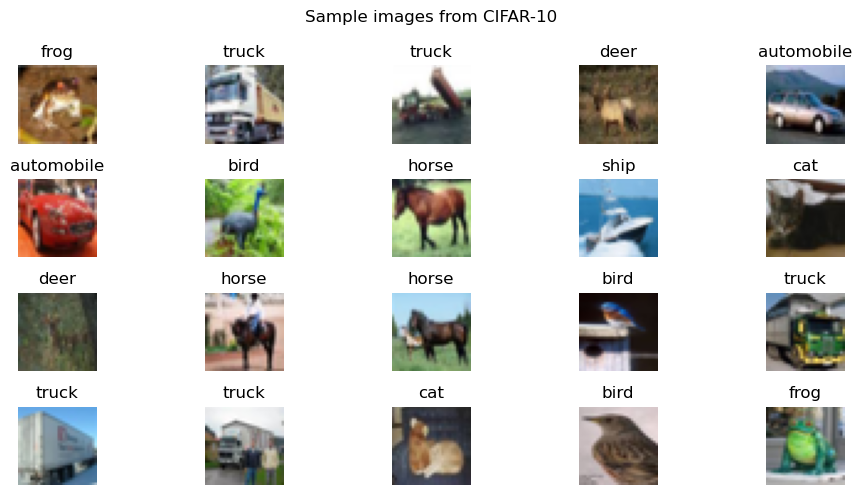

In [5]:
plt.figure(figsize=(10, 5))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample images from CIFAR-10")
plt.tight_layout()
plt.show()

In [6]:
# check class distribution - is it balanced or not
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{class_names[u]}: {c} images")

airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images


In [7]:
# check pixel value range
print("min pixel value:", X_train.min())   
print("max pixel value:", X_train.max())   

min pixel value: 0
max pixel value: 255


## Preprocessing

pixel values are 0-255 - we need to bring them between 0 and 1  
this helps the model learn faster - called normalization

In [8]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print("after normalization - max:", X_train.max())   # 1.0
print("after normalization - min:", X_train.min())   # 0.0

after normalization - max: 1.0
after normalization - min: 0.0


In [10]:
# one-hot encode the labels
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print("y_train before:", y_train[0])        
print("y_train after:",  y_train_ohe[0])    

y_train before: [6]
y_train after: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## ANN Model (Artificial Neural Network)

ANN is simple - only dense layers  
images have to be flattened first because ANN takes 1D input  
32 x 32 x 3 = 3072 values in one line

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),    
    Dense(512, activation='relu'),
    Dropout(0.3),                        # turns off random neurons to stop overfitting
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')      
])

ann_model.summary()

c:\Users\mishr\anaconda3\envs\country\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
ann_history = ann_model.fit(
    X_train, y_train_ohe,
    epochs=20,
    batch_size=64,
    validation_split=0.1,    # 10% of training data used for validation
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2360 - loss: 2.0484 - val_accuracy: 0.3028 - val_loss: 1.9091
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2888 - loss: 1.9218 - val_accuracy: 0.3342 - val_loss: 1.8555
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3046 - loss: 1.8814 - val_accuracy: 0.3528 - val_loss: 1.8182
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3247 - loss: 1.8405 - val_accuracy: 0.3562 - val_loss: 1.7944
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3327 - loss: 1.8187 - val_accuracy: 0.3600 - val_loss: 1.7930
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3390 - loss: 1.8087 - val_accuracy: 0.3722 - val_loss: 1.7489
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3484 - loss: 1.7875 - val_accuracy: 0.3898 - val_loss: 1.7389
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3490 - loss: 1.7765 - val_accu

## ANN Results

evaluate the model on test data and plot training history

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")

ANN Test Accuracy: 0.4242


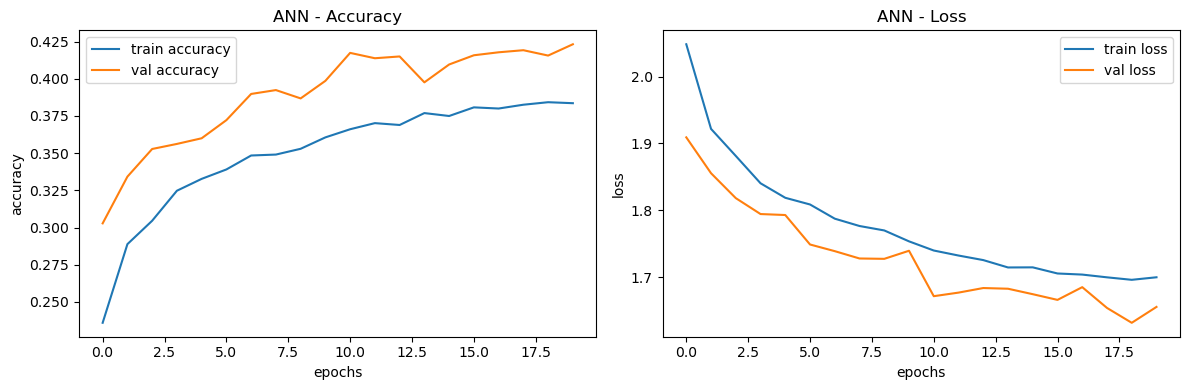

In [15]:
# plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'],     label='train accuracy')
plt.plot(ann_history.history['val_accuracy'], label='val accuracy')
plt.title("ANN - Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'],     label='train loss')
plt.plot(ann_history.history['val_loss'], label='val loss')
plt.title("ANN - Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

## CNN Model (Convolutional Neural Network)

CNN is better for images than ANN  
- Conv2D layer = finds patterns in images (edges, shapes, colors)  
- MaxPooling = reduces image size while keeping important features  
- BatchNormalization = makes training more stable  
- Flatten = converts CNN output to 1D for final dense layers

In [16]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization

cnn_model = Sequential([

    # block 1 - learns basic features like edges
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # block 2 - learns more complex features like shapes
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # block 3 - learns high level features like object parts
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # fully connected layers - final classification
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')   # 10 output classes
])

cnn_model.summary()

c:\Users\mishr\anaconda3\envs\country\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
cnn_history = cnn_model.fit(
    X_train, y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.3648 - loss: 1.7504 - val_accuracy: 0.4420 - val_loss: 1.7130
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.5205 - loss: 1.3295 - val_accuracy: 0.6456 - val_loss: 1.0194
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6049 - loss: 1.1215 - val_accuracy: 0.6868 - val_loss: 0.9006
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6537 - loss: 0.9954 - val_accuracy: 0.6716 - val_loss: 0.9993
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.6831 - loss: 0.9121 - val_accuracy: 0.7150 - val_loss: 0.8452
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.7075 - loss: 0.8504 - val_accuracy: 0.7330 - val_loss: 0.8009
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.7255 - loss: 0.7955 - val_accuracy: 0.7524 - val_loss: 0.7306
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.7355 - loss: 0.7645 - 

## CNN Results

In [19]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

CNN Test Accuracy: 0.8330


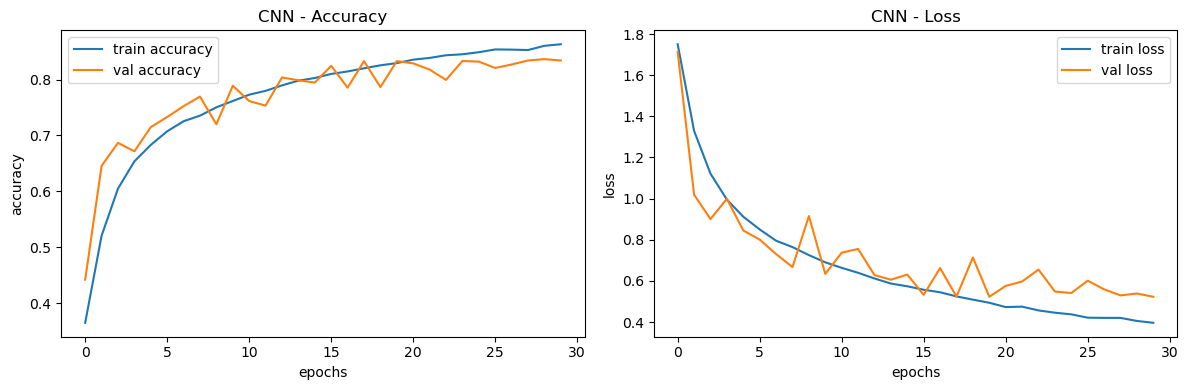

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'],     label='train accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='val accuracy')
plt.title("CNN - Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'],     label='train loss')
plt.plot(cnn_history.history['val_loss'], label='val loss')
plt.title("CNN - Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

plt.tight_layout()
plt.show()

## Training Strategy

### 1. Data Augmentation

augmentation means randomly modifying training images  
the model sees more variety so it learns better  
also reduces overfitting

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,        # rotate image slightly
    width_shift_range=0.1,    # shift left or right
    height_shift_range=0.1,   # shift up or down
    horizontal_flip=True,     # mirror the image
    zoom_range=0.1            # zoom in slightly
)

datagen.fit(X_train)

In [22]:
cnn_aug_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# split validation data separately
X_val       = X_train[:5000]
y_val       = y_train_ohe[:5000]
X_train_aug = X_train[5000:]
y_train_aug = y_train_ohe[5000:]

cnn_aug_history = cnn_aug_model.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=64),
    epochs=30,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.3218 - loss: 1.8700 - val_accuracy: 0.4326 - val_loss: 1.6183
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.4366 - loss: 1.5431 - val_accuracy: 0.5392 - val_loss: 1.2780
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.5123 - loss: 1.3595 - val_accuracy: 0.5040 - val_loss: 1.5543
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5679 - loss: 1.2278 - val_accuracy: 0.6436 - val_loss: 1.0174
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5984 - loss: 1.1474 - val_accuracy: 0.6586 - val_loss: 1.0272
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.6271 - loss: 1.0726 - val_accuracy: 0.6680 - val_loss: 0.9581
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.6476 - loss: 1.0277 - val_accuracy: 0.6436 - val_loss: 1.0760
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.6622 - loss: 0.9875 - 

In [23]:
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"CNN with Augmentation Test Accuracy: {cnn_aug_test_acc:.4f}")

CNN with Augmentation Test Accuracy: 0.7621


### 2. Learning Rate Scheduler

learning rate = how big of a step the model takes while learning  
start with a big step, then take smaller steps later = better results

In [24]:
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
    lr = 0.001
    if epoch > 20:
        lr = 0.0005
    if epoch > 25:
        lr = 0.0001
    return lr

lr_callback = LearningRateScheduler(lr_schedule)

# retrain cnn model with lr scheduler
cnn_model.fit(
    X_train, y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_callback],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.8672 - loss: 0.3877 - val_accuracy: 0.8436 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.8687 - loss: 0.3807 - val_accuracy: 0.8146 - val_loss: 0.6734 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.8685 - loss: 0.3733 - val_accuracy: 0.8480 - val_loss: 0.4976 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.8711 - loss: 0.3647 - val_accuracy: 0.8388 - val_loss: 0.5362 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.8733 - loss: 0.3602 - val_accuracy: 0.8508 - val_loss: 0.4837 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.8790 - loss: 0.3536 - val_accuracy: 0.8432 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.8806 - l

## Compare All Models

In [25]:
print("=" * 40)
print("Model Comparison")
print("=" * 40)
print(f"ANN accuracy:                {ann_test_acc:.4f}")
print(f"CNN accuracy:                {cnn_test_acc:.4f}")
print(f"CNN + Augmentation accuracy: {cnn_aug_test_acc:.4f}")
print("=" * 40)

Model Comparison
ANN accuracy:                0.4242
CNN accuracy:                0.8330
CNN + Augmentation accuracy: 0.7621


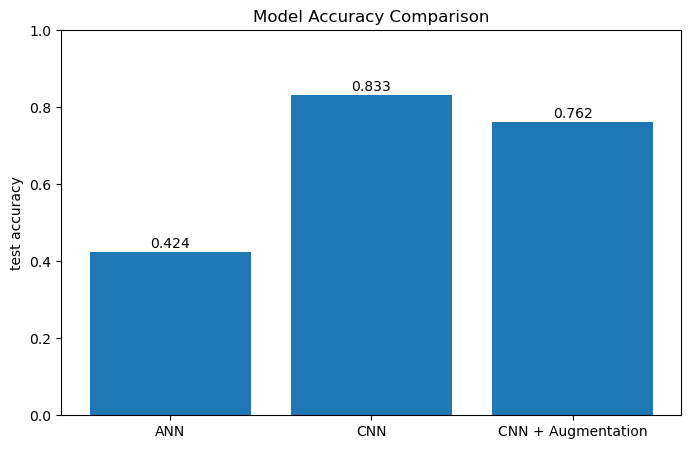

In [26]:
# bar chart comparison
model_names = ['ANN', 'CNN', 'CNN + Augmentation']
accuracies  = [ann_test_acc, cnn_test_acc, cnn_aug_test_acc]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("test accuracy")
plt.ylim(0, 1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center')
plt.show()

## Confusion Matrix

confusion matrix shows which classes the model is getting wrong 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


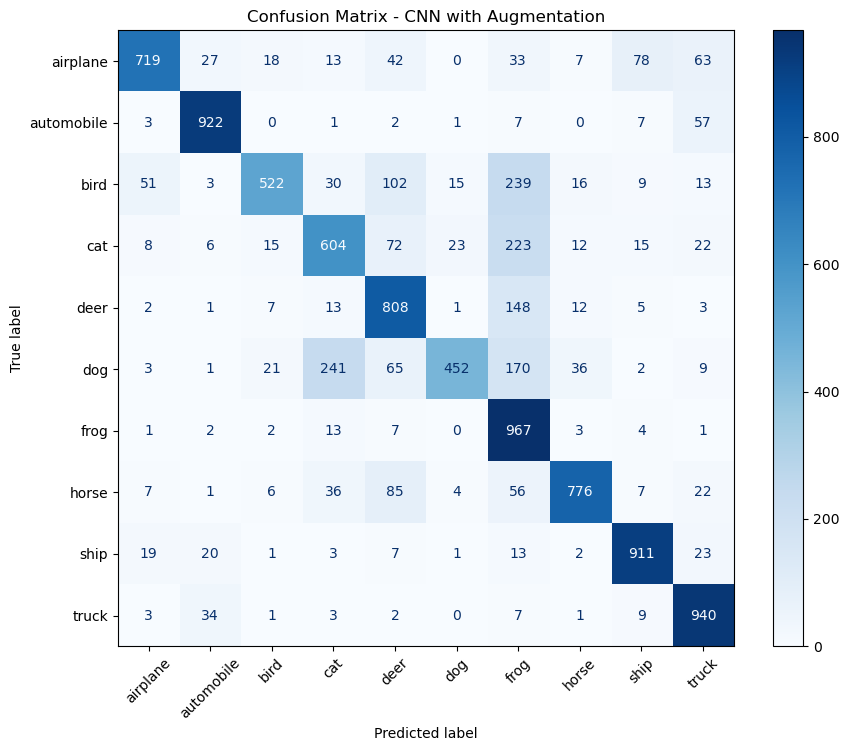

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred         = cnn_aug_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Confusion Matrix - CNN with Augmentation")
plt.xticks(rotation=45)
plt.show()

# rows = actual labels
# columns = predicted labels
# diagonal = correct predictions

## Checking Wrong Predictions

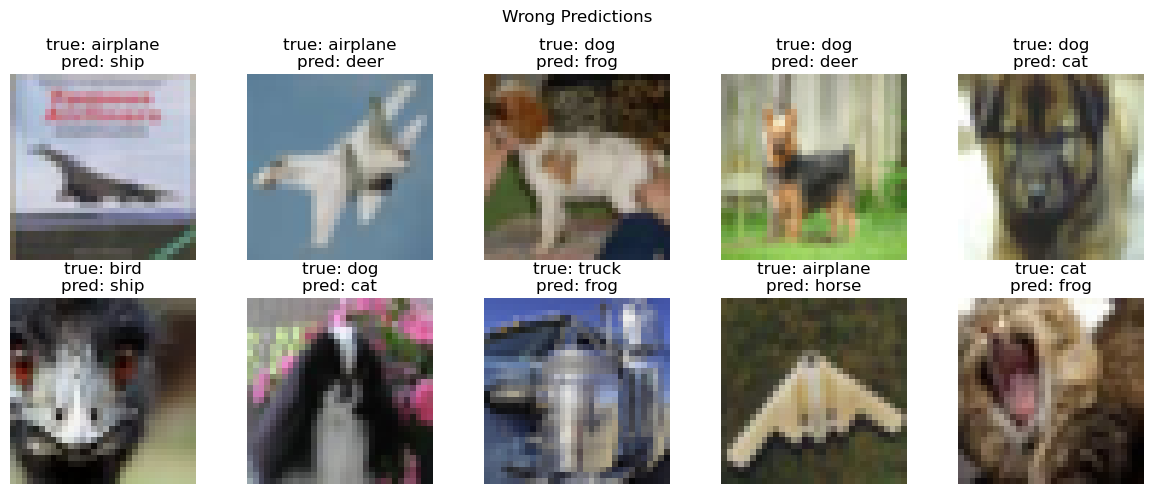

In [28]:
wrong_idx = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(12, 5))
for i in range(10):
    idx = wrong_idx[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"true: {class_names[y_true[idx]]}\npred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')
plt.suptitle("Wrong Predictions")
plt.tight_layout()
plt.show()

## Save the Model

In [29]:
cnn_aug_model.save('cifar10_cnn_model.h5')
print("model saved")

# to load it later:
# from tensorflow.keras.models import load_model
# model = load_model('cifar10_cnn_model.h5')

model saved


## Theory Notes

**ANN (Artificial Neural Network)**
- only Dense layers
- image has to be flattened to 3072 values
- spatial information is lost - that is why it is weak for images
- CIFAR-10 accuracy ~ 45-55%

**CNN (Convolutional Neural Network)**
- Conv2D layers find patterns in images
- spatial information is preserved
- best choice for image tasks
- CIFAR-10 accuracy ~ 70-80%

**Conv2D** = applies a filter on the image - detects edges, shapes  
**MaxPooling** = reduces image size by half - keeps important features  
**BatchNormalization** = stabilizes training - model converges faster  
**Dropout** = randomly turns off neurons - stops overfitting  

**Data Augmentation** = randomly modifying training images
- model sees more variety
- overfitting reduces
- test accuracy improves

**Learning Rate** = how big of a step the model takes per update
- high LR = learns fast but can miss the target
- low LR = learns slow but more accurate
- scheduler = start high then go low = best of both

**Overfitting** = model is good on training but bad on test data
- happens with too many epochs
- prevented by dropout and augmentation

**Epochs** = how many times the model sees the full training data  
**Batch size** = how many images processed at one time  
**Softmax** = used in output layer - gives 10 probabilities that sum to 1  

---

## Expected Results

| model | expected accuracy |
|---|---|
| ANN | 45% - 55% |
| CNN | 70% - 78% |
| CNN + Augmentation | 75% - 82% |

CNN is always better than ANN for images - because spatial features are preserved